##### ***序列模型***
###### 不同于卷积模型，序列模型更关注时间信息而非空间信息，且与之不同的还有卷积模型的输入基本都是独立的随机变量，而序列模型的输入是时间序列，是不独立的随机变量。为此，想要描述这些现象，我们需要一种专门的统计工具。
###### 假设我们在时间t观察到$x_t$，那么得到$T$个不独立的随机变量$x_1,x_2,...,x_T$，它们的联合分布记为$p(x)$，使用条件概率展开可得：$p(a,b) = p(a|b)p(b) = p(a)p(b|a)$<br>所以$p(x) = p(x_1) \cdot p(x_2|x_1) \cdot p(x_3|x_1, x_2) \cdots \cdot p(x_T|x_{T-1}, \cdots, x_1)$由此可见，如果要想知道最后一个$p(x_T)$的概率，我们需要知道$T$之前所有变量出现的概率，也就是说从过去推导未来。反之，我们也可以从未来推导过去，只不过此过程在物理上不一定可行。
###### 所以为求$p(x_T)$，我们需要对$T$之前的变量进行数据建模，也称自回归模型。用之前的数据训练一个模型，然后预测下一个数据。为此有两种主流的方案：马尔科夫假设和潜变量模型。
##### ***马尔科夫假设***
###### 马尔科夫假设是说，当前数据只跟$\tau$个过去的数据点相关，而跟更早的数据点不相关。$p(x_t|x_1, \cdots, x_{t-1}) = p(x_t|x_{t-\tau}, \cdots, x_{t-1})$
##### ***潜变量模型***
###### 我们引入一个潜变量$h_t$来表示过去的所有信息，$h_t = f(x_1, \cdots, x_{t-1})$，所以$x_t = p(x_t|h_t)$

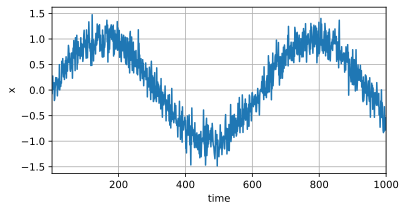

In [5]:
# 利用马尔科夫假设，训练MLP来预测数据：
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

T = 1000
time = torch.arange(1, T+1, dtype=torch.float32)
x = torch.sin(0.01 * time) + torch.normal(0, 0.2, size=(T,))
d2l.plot(time, [x], 'time', 'x', xlim=[1, T], figsize=(6, 3))

In [8]:
# 利用马尔科夫假设生成数据对：
tau = 4
features = torch.zeros((T-tau, tau)) # 形状：(样本数-tau, tau)
# 生成特征矩阵：
for i in range(tau):
    features[:, i] = x[i:T - tau + i]
labels = x[tau:].reshape((-1, 1)) # 即要预测的目标值

batch_size, n_train = 32, 600
train_iter = d2l.load_array((features[:n_train], labels[:n_train]), batch_size, is_train=True)

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)

def get_net():
    net = nn.Sequential(
        nn.Linear(4, 10),
        nn.ReLU(),
        nn.Linear(10, 1)
    )
    net.apply(init_weights)
    return net

loss = nn.MSELoss()

def train(net, train_iter, loss, epochs, lr):
    trainer = torch.optim.Adam(net.parameters(), lr=lr)
    for epoch in range(epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            trainer.step()
        print(f'epoch {epoch+1},'
              f'loss: {d2l.evaluate_loss(net, train_iter, loss):.6f}')

net = get_net()
train(net, train_iter, loss, 5, 0.01)

epoch 1,loss: 0.103163
epoch 2,loss: 0.061868
epoch 3,loss: 0.054971
epoch 4,loss: 0.052694
epoch 5,loss: 0.051799


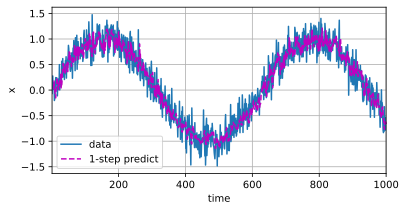

In [10]:
onestep_predict = net(features)
d2l.plot(
    [time, time[tau:]],
    [x.detach().numpy(), onestep_predict.detach().numpy()],
    'time', 'x',
    legend=['data', '1-step predict'], xlim = [1, 1000], figsize=(6, 3)
    )


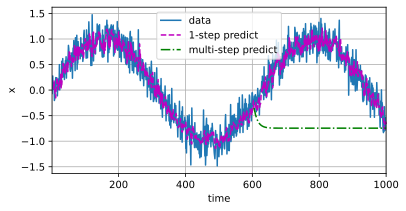

In [14]:
multistep_preds = torch.zeros(T)
multistep_preds[:n_train + tau] = x[:n_train + tau] # 前n_train + tau个位置用真实值
for i in range(n_train + tau, T):
    multistep_preds[i] = net(multistep_preds[i - tau:i].reshape((1, -1)))

d2l.plot(
    [time, time[tau:], time[n_train + tau:]],
    [x.detach().numpy(), onestep_predict.detach().numpy(), multistep_preds[n_train + tau:].detach().numpy()],
    'time', 'x',
    legend=['data', '1-step predict', 'multi-step predict'], xlim = [1, 1000], figsize=(6, 3)
    )

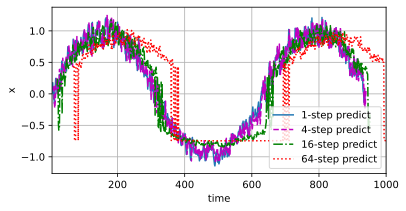

In [ ]:
max_step = 64
features = torch.zeros((T-tau-max_step + 1, tau + max_step))
for i in range(tau):
    features[:, i] = x[i:i + T - tau - max_step + 1]

for i in range(tau, tau + max_step): # 预测未来max_step步
    features[:, i] = net(features[:, i - tau:i]).reshape(-1)

steps = [1, 4, 16, 64]
d2l.plot(
    [time[tau + i - 1:T - max_step + i] for i in steps],
    [features[:, (tau + i - 1)].detach().numpy() for i in steps],
    'time', 'x', legend=[f'{i}-step predict' 
                        for i in steps], xlim = [5, 1000], figsize=(6, 3))